# **1. LSTM**

LSTM(Long Short-Term Memory)은 RNN의 장기 의존성 문제를 해결하기 위해 고안된 모델입니다. LSTM은 셀 상태(cell state)와 3개의 게이트(입력 게이트, 출력 게이트, 망각 게이트)를 사용하여 중요한 정보를 오랫동안 저장하고 불필요한 정보를 제거하는 구조를 갖추고 있습니다. 망각 게이트는 이전 셀 상태에서 필요 없는 정보를 삭제하고, 입력 게이트는 새로운 정보를 저장하며, 출력 게이트는 최종 출력을 결정합니다. 이러한 구조 덕분에 LSTM은 장기 시퀀스를 다루는 자연어 처리, 음성 인식, 시계열 예측 등의 다양한 분야에서 효과적으로 사용됩니다. 하지만 구조가 복잡하여 계산량이 많고, 학습 시간이 오래 걸린다는 단점이 있습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcZc3hM%2FbtsMdnHhWNo%2FAAAAAAAAAAAAAAAAAAAAAF4oC6n3Ej3NTx0j2gyx0wMXYTBr1UsoM47l5nW0rhiE%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3DIQZ4YftXtXcG7UMmf7%252FlGsbLHRk%253D' width=500>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FrEcov%2FbtsMcfJ7ypD%2FAAAAAAAAAAAAAAAAAAAAAA_hhR3wl82-F2L8NpK3KgCmAitfjPvvBVPlHmCM0Qqa%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3DG%252BRjorMF2JqROTf36QAqBN4hM8Y%253D'>

### 1-1. 망각게이트
망각 게이트는 이전 정보를 얼마나 유지하고 버릴지를 결정한다. 즉, 불필요한 정보는 삭제하고, 중요한 정보만 남긴다.
시그모이드 함수(0, 1)로 변환한 값을 출력한다.

### 1-2. 입력게이트
입력 게이트는 현재 입력된 정보를 기억할 지 결정한다. 즉, 새로운 정보를 LSTM에 추가할 지 조절한다. tanh을 사용하여 새롭게 저장할 정보의 후보값을 저장한다.

### 1-3. 출력 게이트
출력 게이트는 현재 상태에서 어떤 정보를 출력할 지 결정한다. 즉, LSTM이 다음 타임스텝으로 넘겨줄 정보를 조절한다. tanh 함수를 사용하여 변환한 후 지금까지 얻어온 정보를 곱해 최종 은닉 상태를 만든다.

In [ ]:
!pip install konlpy  # 한국어 형태소 분석기
!pip install mecab-python
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 39.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.2/591.2 kB 27.9 MB/s eta 0:00:00
  Created wheel for mecab-python: filename=mecab_python-1.0.0-py3-none-any.whl size=1232 sha256=2b9aafa772f117c07612f4006d99959a8bcc7a46e0d4f0cdbbe2c8df5b23266a
  Stored in directory: /root/.cache/pip/wheels/62/0e/84/39e1c8bf2f2da63964fe43fb2932027d6344f8766edf28bc8c
Successfully built mecab-python
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1381k  100 1381k    0     0   440k      0  0:00:03  0:00:03 --:--:-- 1057k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/exam

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
from konlpy.tag import Mecab
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# 데이터 로드
url = 'https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt'
data = pd.read_table(url, names=['rating', 'review'])

# 3점 리뷰 제거 후 긍정(1), 부정(0) 라벨링
data = data[data['rating'] != 3]
data['label'] = np.where(data['rating'] > 3, 1, 0)
data

,rating,review,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,0
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,1
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,1
199998,5,넘이쁘고 쎄련되보이네요~,1


In [ ]:
# 한글 텍스트만 남기기
def preprocess_text(text):
    text = re.sub(r'[^가-힣\s]', '', text)
    return text

data['review'] = data['review'].apply(preprocess_text)

# 형태소 분석기 적용
mecab = Mecab()
stopwords = ['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를']  # 불용어 등록

def tokenize(text):
    tokens = mecab.morphs(text)
    return [token for token in tokens if token not in stopwords]  # 불용어에 해당하지 않는 것들만 반환

data['tokenized'] = data['review'].apply(tokenize)
data

,rating,review,label,tokenized
0,5,배공빠르고 굿,1,"[배공, 빠르, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,"[택배, 엉망, 네, 용, 저희, 집, 밑, 층, 말, 없이, 놔두]"
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...,1,"[아주, 좋, 아요, 바지, 정말, 좋, 아서, 개, 더, 구매, 했, 어요, 가격..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다 전화...,0,"[선물, 용, 으로, 빨리, 받, 아서, 전달, 했어야, 상품, 었, 는데, 머그,..."
4,5,민트색상 예뻐요 옆 손잡이는 거는 용도로도 사용되네요,1,"[민트, 색상, 예뻐요, 옆, 손잡이, 거, 용도, 로, 사용, 되, 네요]"
...,...,...,...,...
199995,2,장마라그런가 달지않아요,0,"[장마, 라, 그런가, 달, 지, 않, 아요]"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,1,"[다이슨, 케이스, 구매, 했, 어요, 다이슨, 슈퍼, 소닉, 드라, 이기, 케이스..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 자주이용할께요,1,"[로드, 샾, 에서, 사, 것, 보다, 세배, 저렴, 네요, 자주, 이용, 할께요]"
199998,5,넘이쁘고 쎄련되보이네요,1,"[넘, 이쁘, 쎄, 련, 되, 보이, 네요]"


In [ ]:
# 단어 사전 생성
all_tokens = [token for tokens in data['tokenized'] for token in tokens]  # 토큰화된 전체 문서에서 모든 토큰을 하나의 리스트로 모으기
all_tokens

['배공',
 '빠르',
 '굿',
 '택배',
 '엉망',
 '네',
 '용',
 '저희',
 '집',
 '밑',
 '층',
 '말',
 '없이',
 '놔두',
 '아주',
 '좋',
 '아요',
 '바지',
 '정말',
 '좋',
 '아서',
 '개',
 '더',
 '구매',
 '했',
 '어요',
 '가격',
 '대박',
 '입니다',
 '바느질',
 '조금',
 '엉성',
 '긴',
 '지만',
 '편하',
 '성비',
 '최고',
 '예요',
 '선물',
 '용',
 '으로',
 '빨리',
 '받',
 '아서',
 '전달',
 '했어야',
 '상품',
 '었',
 '는데',
 '머그',
 '컵',
 '만',
 '와서',
 '당황',
 '했',
 '습니다',
 '전화',
 '했',
 '더니',
 '바로',
 '주',
 '신다',
 '했',
 '지만',
 '배송',
 '누락',
 '되',
 '어',
 '있',
 '었',
 '네요',
 '확인',
 '안',
 '바로',
 '선물',
 '했',
 '으면',
 '큰일날',
 '뻔',
 '했',
 '네요',
 '이렇게',
 '배송',
 '오래',
 '걸렸',
 '으면',
 '사',
 '거',
 '다시',
 '생각',
 '했',
 '거',
 '같',
 '아요',
 '아쉽',
 '네요',
 '민트',
 '색상',
 '예뻐요',
 '옆',
 '손잡이',
 '거',
 '용도',
 '로',
 '사용',
 '되',
 '네요',
 '비추',
 '합니다',
 '계란',
 '뒤집',
 '때',
 '완전',
 '불편',
 '해요',
 '코팅',
 '묻어나',
 '보',
 '기',
 '엔',
 '예쁘',
 '실용',
 '적',
 '으로',
 '보였',
 '는데',
 '생각',
 '보다',
 '진짜',
 '별로',
 '입니다',
 '주문',
 '월',
 '시켰',
 '는데',
 '월일',
 '배송',
 '왔',
 '네요',
 '여기',
 '회사',
 '측',
 '과',
 '전화',
 '안',
 '되',
 '아무런',
 '연락',
 '

In [ ]:
vocab = Counter(all_tokens)  # 토큰 등장 빈도수
vocab

Counter({'배공': 10,
         '빠르': 7699,
         '굿': 3084,
         '택배': 2241,
         '엉망': 735,
         '네': 2831,
         '용': 5036,
         '저희': 719,
         '집': 2829,
         '밑': 659,
         '층': 166,
         '말': 2422,
         '없이': 2583,
         '놔두': 104,
         '아주': 5096,
         '좋': 65731,
         '아요': 39801,
         '바지': 701,
         '정말': 5592,
         '아서': 12218,
         '개': 8783,
         '더': 9866,
         '구매': 33361,
         '했': 28446,
         '어요': 44163,
         '가격': 11422,
         '대박': 500,
         '입니다': 10728,
         '바느질': 336,
         '조금': 4589,
         '엉성': 278,
         '긴': 4696,
         '지만': 12517,
         '편하': 3717,
         '성비': 1494,
         '최고': 1820,
         '예요': 2918,
         '선물': 3127,
         '으로': 13772,
         '빨리': 1587,
         '받': 9822,
         '전달': 72,
         '했어야': 46,
         '상품': 5642,
         '었': 12704,
         '는데': 42522,
         '머그': 12,
         '컵': 468,
         '

In [ ]:
vocab_size = len(vocab) + 2  # len(vocab): 실제 단어의 수,  +2: <PAD>, <OOV> 고려
vocab_size

41130

In [ ]:
word_to_index = {word: idx + 2 for idx, (word, _) in enumerate(vocab.most_common())}
word_to_index['<PAD>'] = 0
word_to_index['<OOV>'] = 1

word_to_index

{'네요': 2,
 '좋': 3,
 '어요': 4,
 '는데': 5,
 '아요': 6,
 '잘': 7,
 '있': 8,
 '구매': 9,
 '안': 10,
 '게': 11,
 '습니다': 12,
 '배송': 13,
 '너무': 14,
 '했': 15,
 '같': 16,
 '지': 17,
 '거': 18,
 '어': 19,
 '먹': 20,
 '합니다': 21,
 '되': 22,
 '재': 23,
 '요': 24,
 '기': 25,
 '쓰': 26,
 '않': 27,
 '없': 28,
 '것': 29,
 '아': 30,
 '로': 31,
 '해서': 32,
 '사용': 33,
 '았': 34,
 '나': 35,
 '들': 36,
 '으로': 37,
 '만': 38,
 '보다': 39,
 '었': 40,
 '겠': 41,
 '주': 42,
 '지만': 43,
 '보': 44,
 '그냥': 45,
 '아서': 46,
 '해': 47,
 '제품': 48,
 '서': 49,
 '어서': 50,
 '면': 51,
 '가격': 52,
 '해요': 53,
 '좀': 54,
 '생각': 55,
 '만족': 56,
 '주문': 57,
 '입니다': 58,
 '라': 59,
 '니': 60,
 '더': 61,
 '받': 62,
 '맛': 63,
 '할': 64,
 '많이': 65,
 '개': 66,
 '사': 67,
 '시': 68,
 '때': 69,
 '사이즈': 70,
 '에서': 71,
 '듯': 72,
 '작': 73,
 '빠르': 74,
 '번': 75,
 '왔': 76,
 '샀': 77,
 '음': 78,
 '맛있': 79,
 '별로': 80,
 '포장': 81,
 '두': 82,
 '수': 83,
 '입': 84,
 '맞': 85,
 '던': 86,
 '다른': 87,
 '저렴': 88,
 '괜찮': 89,
 '세요': 90,
 '넘': 91,
 '못': 92,
 '상품': 93,
 '데': 94,
 '정말': 95,
 '아니': 96,
 '에요': 97,
 '하나'

In [ ]:
word_to_index['<PAD>']

0

In [ ]:
word_to_index['<OOV>']

1

In [ ]:
# 정수 인코딩
def encode_tokens(tokens):
    return [word_to_index.get(token, 1) for token in tokens]

data['encoded'] = data['tokenized'].apply(encode_tokens)
data['tokenized']

,tokenized
0,"[배공, 빠르, 굿]"
1,"[택배, 엉망, 네, 용, 저희, 집, 밑, 층, 말, 없이, 놔두]"
2,"[아주, 좋, 아요, 바지, 정말, 좋, 아서, 개, 더, 구매, 했, 어요, 가격..."
3,"[선물, 용, 으로, 빨리, 받, 아서, 전달, 했어야, 상품, 었, 는데, 머그,..."
4,"[민트, 색상, 예뻐요, 옆, 손잡이, 거, 용도, 로, 사용, 되, 네요]"
...,...
199995,"[장마, 라, 그런가, 달, 지, 않, 아요]"
199996,"[다이슨, 케이스, 구매, 했, 어요, 다이슨, 슈퍼, 소닉, 드라, 이기, 케이스..."
199997,"[로드, 샾, 에서, 사, 것, 보다, 세배, 저렴, 네요, 자주, 이용, 할께요]"
199998,"[넘, 이쁘, 쎄, 련, 되, 보이, 네요]"


In [ ]:
# 패딩 적용
max_len = 100

def pad_sequence(seq, max_len):
    return seq[:max_len] + [0] * (max_len - len(seq))

data['padded'] = data['encoded'].apply(lambda x: pad_sequence(x, max_len))  # 100이 채워지지 않으면 0으로 채워 padding된 date로 반환
data['padded']  # padding으로 채우는 이유: 벡터의 길이을 맞춰서 내적을 구하기 위해 전체적으로 길이를 맞춘다.

,padded
0,"[9338, 74, 166, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[226, 557, 185, 104, 564, 186, 594, 1743, 209,..."
2,"[102, 3, 6, 569, 95, 3, 46, 66, 61, 9, 15, 4, ..."
3,"[163, 104, 37, 295, 62, 46, 3079, 4104, 93, 40..."
4,"[2358, 174, 297, 617, 539, 18, 997, 31, 33, 22..."
...,...
199995,"[7139, 59, 943, 138, 17, 27, 6, 0, 0, 0, 0, 0,..."
199996,"[7090, 385, 9, 15, 4, 7090, 2880, 19042, 3436,..."
199997,"[4164, 12543, 71, 67, 29, 39, 22688, 88, 2, 37..."
199998,"[91, 198, 1907, 11071, 22, 240, 2, 0, 0, 0, 0,..."


In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, reviews, labels):
        self.reviews = torch.tensor(reviews, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        return self.reviews[idx], self.labels[idx]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(data['padded'].tolist(), data['label'].tolist(), test_size=0.2, random_state=2025)  # padding된 데이터를 리스트로 만들어서 분할

# DataLoader
batch_size = 64
train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)



In [ ]:
len(train_dataset), len(test_dataset)

(160000, 40000)

In [ ]:
train_dataset[0], test_dataset[0]

((tensor([3571,  143, 2197,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0]),
  tensor(0.)),
 (tensor([6034, 5430, 6756, 6006,  368,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,  

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)  # 배치 정규화 추가
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = self.batch_norm(lstm_out[:, -1, :])  # 배치 정규화 적용
        out = self.fc(out)
        return out  # BCEWithLogitsLoss 내부에서 sigmoid 적용됨

# 모델 초기화
embedding_dim = 128
hidden_dim = 512  # 은닉 차원 증가
output_dim = 1
n_layers = 2
dropout = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout)
model.to(device)

SentimentLSTM(
  (embedding): Embedding(41130, 128)
  (lstm): LSTM(128, 512, num_layers=2, batch_first=True, dropout=0.2)
  (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

### AdamW
* Adam: 학슬할 때 가중치를 업데이트하면서 L2 정규화를 하는데,
이 정규화를 잘못된 방식으로 처리되어 실제로 L2 정규화가 적용되지 않을 때가 있음. (학습 + 정규화)
* AdamW: 정규화를 빼고 다시 만든 방식(Adam + weight decay를 분리해서 정확히 적용)

> adam보다 더 안정적이고 잘 동작함. 특히 Transformer 계열, BERT, GPT 등 adamW를 씀. [논문](https://arxiv.org/pdf/1711.05101)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

def train_model(model, train_loader, criterion, optimizer, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0
        correct = 0
        total = 0

        for reviews, labels in train_loader:
            reviews, labels = reviews.to(device), labels.to(device)

            optimizer.zero_grad()
            predictions = model(reviews).squeeze()  # squeeze(): 차원의 1이되어 있는 것을 없애줌
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (torch.sigmoid(predictions) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)  # 라벨 개수 세기

        epoch_acc = correct / total
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, Accuracy: {epoch_acc:.4f}')

# 학습 실행
train_model(model, train_loader, criterion, optimizer, 5)

Epoch 1/5, Loss: 0.5200, Accuracy: 0.6818
Epoch 2/5, Loss: 0.2457, Accuracy: 0.9092
Epoch 3/5, Loss: 0.2056, Accuracy: 0.9265
Epoch 4/5, Loss: 0.1716, Accuracy: 0.9410
Epoch 5/5, Loss: 0.1387, Accuracy: 0.9543


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()  # 테스트(평가) 모드 (Dropout, BatchNorm 등을 비활성화)
    correct = 0  # 예측이 맞은 개수
    total = 0  # 전체 샘플 개수
    predictions_list = []  # 모델의 예측 결과들을 저장하는 리스트
    labels_list = []  # 실제 정답 라벨들을 저장하는 리스트

    with torch.no_grad():  # 평가 시에는 gradient 계산을 하지 않도록 설정 → 메모리 절약 + 속도 향상
        for reviews, labels in test_loader:
            reviews, labels = reviews.to(device), labels.to(device)
            predictions = model(reviews).squeeze()  # 모델에 리뷰 입력을 넣어 예측값을 얻는다. .squeeze(): 불필요한 차원 제거.
            preds = (predictions >= 0.5).float()  # 0.5이상 → 1 , 아니면 0 (이진분류 결과), float형으로 변환(0.0 or 1.0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # GPU에 있을 수 있는 preds와 labels를 CPU로 옮겨 numpy 배열로 변환한 뒤 리스트에 추가
            predictions_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    accuracy = accuracy_score(labels_list, predictions_list)  # sklearn의 accuracy_score를 이용해 전체 정확도(Accuracy) 계산
    print(f'Test Accuracy: {accuracy:.4f}')

# 평가 실행
evaluate_model(model, test_loader)

Test Accuracy: 0.9161


In [ ]:
def predict_sentiment(model, sentence):
    model.eval()
    tokens = tokenize(sentence)  # 문장을 토큰화한다.  (예: "이 제품 정말 좋아요!" → ["이", "제품", "정말", "좋아요", "!"])
    encoded = encode_tokens(tokens)  # 토큰들을 숫자로 인코딩(정수 매핑) (예: ["정말", "좋아요"] → [15, 39])
    padded = pad_sequence(encoded, max_len)  # 인코딩된 숫자 시퀀스를 max_len 길이만큼 패딩 (예: [15, 39] → [15, 39, 0, 0, 0] (0은 <PAD>))

    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)
    # 패딩된 리스트를 PyTorch의 텐서로 변환하고, 디바이스로 이동
    # []로 한 번 감싸는 이유: 배치 형태로 만들어야 하니까 → [sequence] → [1, sequence_length]

    with torch.no_grad():
        prediction = model(input_tensor).item()  # 모델에 입력 텐서를 넣고 예측값(raw output/logit)을 가져옴. .item()은 텐서를 숫자로 변환
        probability = torch.sigmoid(torch.tensor(prediction)).item()  # 확률로 변환(예측값은 logit이므로 시그모이드를 통해 확률값(0~1))
    sentiment = "긍정" if probability >= 0.5 else "부정"
    print(f"입력 문장: {sentence}")
    print(f"예측 확률: {probability:.4f} ({sentiment})")

# 테스트
test_sentences = [
    "이 제품 정말 좋아요! 추천합니다.",
    "완전 별로예요. 사지 마세요.",
    "기대 이하입니다. 실망했어요."
]

for sentence in test_sentences:
    predict_sentiment(model, sentence)

입력 문장: 이 제품 정말 좋아요! 추천합니다.
예측 확률: 0.9795 (긍정)
입력 문장: 완전 별로예요. 사지 마세요.
예측 확률: 0.0029 (부정)
입력 문장: 기대 이하입니다. 실망했어요.
예측 확률: 0.0024 (부정)


In [ ]:
test_sentences = [
    "아ㅋ, 그렇구나ㅋ",
    "아ㅋㅋㅋㅋㅋㅋㅋ 그렇구나",
    "진짜?ㅋ"
    "진짜?ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ"
]

for t in texts:
    print('문장: ', texts)
    print("토큰: ", mecab.morphs(t))
    print("품사: ", mecab.pos(t))
    print('-',*50)

NameError: name 'texts' is not defined

# **2. GRU**

GRU(Gated Recurrent Unit)는 2014년 뉴욕대학교(NYU) 조경현(Kyunghyun Cho) 교수 연구팀이 제안한 RNN의 장기 의존성 문제를 해결하기 위해 개발한 신경망 구조입니다. LSTM과 유사한 성능을 가지면서도 더 간단한 구조를 갖고 있어 연산량이 적고 학습 속도가 빠릅니다. GRU는 업데이트 게이트(Update Gate)와 리셋 게이트(Reset Gate)라는 두 개의 게이트만을 사용하여 정보를 조절하며, LSTM보다 파라미터 수가 적어 적은 데이터셋에서도 효과적으로 학습할 수 있습니다. 업데이트 게이트는 이전 정보를 얼마나 유지할지 결정하고, 리셋 게이트는 새로운 정보를 반영하기 위해 기존 정보를 얼마나 잊을지 조정합니다. 이러한 특성 덕분에 GRU는 텍스트 처리, 음성 인식, 시계열 예측 등에서 LSTM보다 더 빠르고 효율적으로 사용할 수 있지만, 장기 의존성이 중요한 경우 LSTM이 더 나은 성능을 보일 수도 있습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FPevsT%2FbtsMcHGdA4O%2FAAAAAAAAAAAAAAAAAAAAAE8EH4nTzqsfSGhp9X3OujNDYktMvEnnZPdFuq_vRTM2%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3DGJbmovZWruN%252FN8o6CaiSjKmFyDo%253D' width=500>
<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FdD3nxq%2FbtsMbVSJZ5d%2FAAAAAAAAAAAAAAAAAAAAAPO0etsLUUbl-8EHGDzbaSSVQqQl3lKLYKwpZKRU4HO0%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3D4HUlEoIUkt0R%252BsS7iwjyUOIIFoQ%253D' width=500>


In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(SentimentGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # LSTM -> GRU 변경
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout, bidirectional=True)
        # bidirectional:
        self.batch_norm = nn.BatchNorm1d(hidden_dim * 2)  # 배치 정규화 추가
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        gru_out, _ = self.gru(embedded)  # GRU 실행
        out = self.batch_norm(gru_out[:, -1, :])  # 마지막 타임스텝의 출력 사용
        out = self.fc(out)
        return out  # BCEWithLogitsLoss 내부에서 sigmoid 적용됨

# 모델 초기화
embedding_dim = 128
hidden_dim = 512
output_dim = 1
n_layers = 2
dropout = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SentimentGRU(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout)
model.to(device)

**※ Bidirectional**

Bidirectional(양방향) RNN은 순방향(forward)과 역방향(backward)으로 정보를 처리하여 입력 시퀀스의 과거와 미래 정보를 모두 활용하는 방식으로, 일반적인 단방향 RNN이 과거에서 현재로만 정보를 전달하는 것과 달리, Bidirectional RNN은 역방향으로도 학습하여 보다 풍부한 문맥 정보를 학습할 수 있어 자연어 처리(NLP)와 시계열 분석에서 유용하게 사용됩니다.  (bidirectional=True 옵션만 추가하면 Bidirectional RNN, LSTM/GRU를 사용할 수 있습니다.)

# **3. LSTM + CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.datasets import reuters       # 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눕니다.
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=1000, test_split=0.2)

In [ ]:
category = np.max(y_train) + 1
print('카테고리: ', category)
print('학습용 뉴스 기사: ',len(X_train))
print('테스트용 뉴스 기사: ', len(X_test))
print(X_train[0])
print(X_train[1])

46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
[1, 2, 699, 2, 2, 56, 2, 2, 9, 56, 2, 2, 81, 5, 2, 57, 366, 737, 132, 20, 2, 7, 2, 49, 2, 2, 2, 2, 699, 2, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2, 2, 2, 775, 7, 48, 34, 191, 44, 35, 2, 505, 17, 12]


In [ ]:
# 단어 수 맞추기
X_train = sequence.pad_sequences(X_train, maxlen=100)  # pad_sequences: 0을 앞에 붙임
X_test = sequence.pad_sequences(X_test, maxlen=100)
X_train[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   2, 699,   2,   2,  56,   2,   2,
         9,  56,   2,   2,  81,   5,   2,  57, 366, 737, 132,  20,   2,
         7,   2,  49,   2,   2,   2,   2, 699,   2,   8,   7,  10, 241,
        16, 855, 129, 231, 783,   5,   4, 587,   2,   2,   2, 775,   7,
        48,  34, 191,  44,  35,   2, 505,  17,  12], dtype=int32)

In [ ]:
# 원핫인코딩 전 확인
y_train[0]

np.int64(3)

In [ ]:
y_train

array([ 3,  4,  3, ..., 25,  3, 25])

In [ ]:
# 원-핫 인코딩 처리
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# 모델 구조 설정(중요! 복습!)
model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, activation='tanh'))
model.add(Dense(46, activation='softmax'))

# 모델의 실행 옵션 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습의 조기 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # val_loss가 연속 5번 이상 좋아지지 않으면 멈추겠다.

# 모델 실행
history = model.fit(X_train, y_train, batch_size=20, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - accuracy: 0.3943 - loss: 2.4639 - val_accuracy: 0.5378 - val_loss: 1.8465
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.5576 - loss: 1.7432 - val_accuracy: 0.5708 - val_loss: 1.6558
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.5983 - loss: 1.5594 - val_accuracy: 0.6305 - val_loss: 1.4806
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.6531 - loss: 1.3759 - val_accuracy: 0.6492 - val_loss: 1.3615
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.6889 - loss: 1.2189 - val_accuracy: 0.6866 - val_loss: 1.2511
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.7332 - loss: 1.0753 - val_accuracy: 0.6981 - val_loss: 1.1927
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 50s 112ms/step - accuracy: 0.7449 - loss: 1.0009 - val_accuracy: 0.7061 - val_loss: 1.1643
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.7707 - loss: 

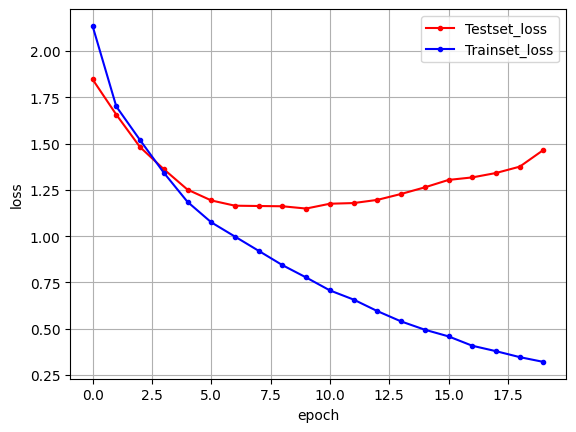

In [ ]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눕니다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 단어의 수를 맞추어 줍니다.
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

# 모델의 구조를 설정합니다.
model = Sequential([
    Input(shape=(None,)),
    Embedding(5000, 100),
    Dropout(0.5),
    Conv1D(64, 5, padding='valid', activation='relu', strides=1),
    MaxPooling1D(pool_size=4),
    LSTM(55),
    Dense(1),
    Activation('sigmoid')
])
model.summary()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, None, 100)      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

-----------------------

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 웹사이트 영화 리뷰
# 긍정(1) 부정(0)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

In [ ]:
# 단어 수 맞추기
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

In [ ]:
# 모델의 구조를 설정합니다.
model = Sequential([
    Input(shape=(None,)),  # None: 가변길이 허용
    Embedding(5000, 100),  # 5000개의 데이터, 100개의 차원
    Dropout(0.5),
    Conv1D(64, 5, padding='valid', activation='relu', strides=1),  # padding='valid': padding을 하지 않겠다.
    MaxPooling1D(pool_size=4),  # stride=4
    LSTM(55),  # 55개의 히든 사이즈로 문장의 의미를 요약
    Dense(1),  # output size
    Activation('sigmoid')
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, None, 100)      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 64)       │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Input(shape=(None,)) : Keras/TensorFlow에서 입력 텐서의 모양을 정의하는 구문.

- shape=(None,)
    - 튜플 한 칸짜리: 시퀀스 길이 축(시간/토큰 길이) 을 뜻한다.
    - None은 가변 길이를 허용한다는 의미.
    - 즉, 한 배치 안에서 각 샘플의 길이가 달라도 받을 수 있도록 정의한다.

- 배치 차원(batch_size)는 여기서 지정하지 않으며, 내부적으로 역시 None으로 둔다.
    → 전체 입력 형태는 (batch_size, sequence_length) 가 되고, sequence_length가 가변이라 None 이다.

**CNN 뒤에 LSTM을 둔 이유**

Conv1D를 먼저 두는 이유는 문장 속 국소 패턴(n-그램)을 빠르게 추출하고(예: 부정 표현, 강한 형용사 등), MaxPooling으로 시간 축을 압축해 노이즈를 줄이고 연산량을 크게 낮춘 뒤 그 순차적 특징열을 LSTM에 넘겨 장기 의존성과 순서 정보를 학습하게 하려는 설계이기 때문입니다. 이렇게 하면 LSTM이 처음부터 긴 시퀀스 전체를 처리하지 않아도 되어 학습이 더 안정적이고 빠르며, CNN이 잡은 특징적인 의미와 LSTM이 학습한 전역 문맥을 결합해 성능과 효율을 동시에 얻을 수 있습니다.

In [ ]:
# 모델의 실행 옵션 설정
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습의 조기 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델 실행
history = model.fit(X_train, y_train, batch_size=40, epochs=100, validation_split=0.25, callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 226ms/step - accuracy: 0.6846 - loss: 0.5494 - val_accuracy: 0.8886 - val_loss: 0.2800
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 256ms/step - accuracy: 0.9079 - loss: 0.2428 - val_accuracy: 0.8918 - val_loss: 0.2624
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 241ms/step - accuracy: 0.9299 - loss: 0.1870 - val_accuracy: 0.8797 - val_loss: 0.3063
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 235ms/step - accuracy: 0.9473 - loss: 0.1446 - val_accuracy: 0.8894 - val_loss: 0.3051
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 235ms/step - accuracy: 0.9603 - loss: 0.1093 - val_accuracy: 0.8883 - val_loss: 0.2998
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 229ms/step - accuracy: 0.9741 - loss: 0.0813 - val_accuracy: 0.8888 - val_loss: 0.3408
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 232ms/step - accuracy: 0.9762 - loss: 0.0753 - val_accuracy: 0.8883 - val_loss: 0.3562
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 233ms/step - accuracy: 

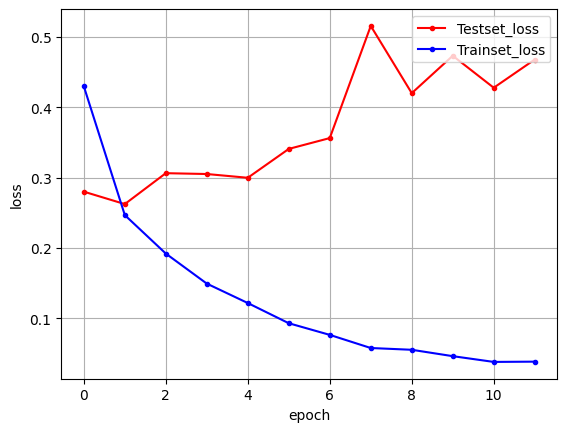

In [ ]:
# 학습셋과 테스트셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 보겠습니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()